In [1]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

Форма изображения: (225, 225) | тип данных: uint8
Мин. яркость: 0 | макс. яркость: 255 | средняя яркость: 130.6


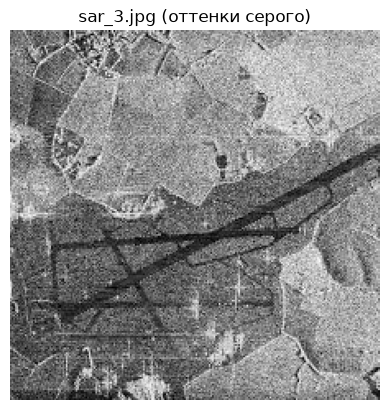

In [2]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Форма изображения:', image_gray.shape, '| тип данных:', image_gray.dtype)
print('Мин. яркость:', image_gray.min(), '| макс. яркость:', image_gray.max(),
      '| средняя яркость:', round(image_gray.mean(), 2))

# на снимке аэродрома видны тёмные полосы (ВПП/дороги) на светлом шумном фоне
plt.imshow(image_gray, cmap='gray')
plt.title('sar_3.jpg (оттенки серого)')
plt.axis('off')
plt.show()

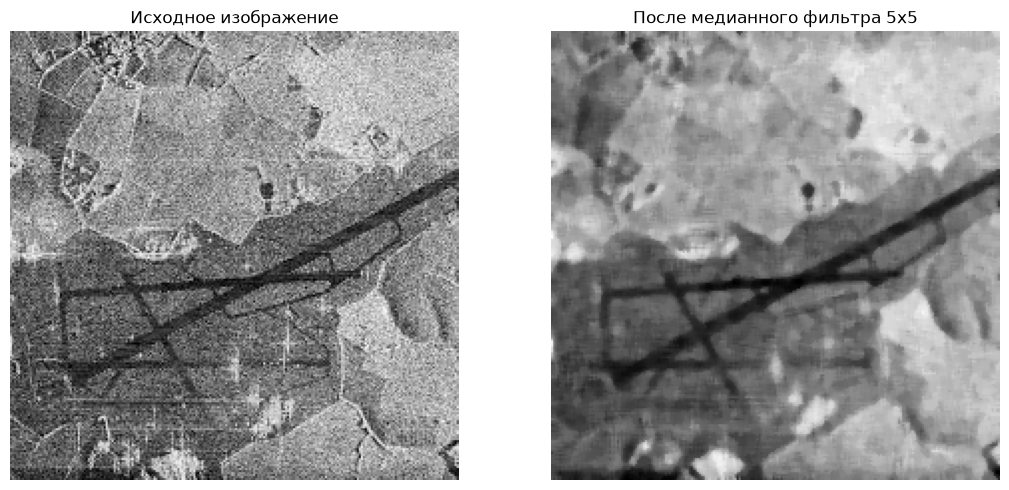

In [3]:
image_med = cv2.medianBlur(image_gray, 5)

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_med, cmap='gray')
plt.title('После медианного фильтра 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

## Хаф
Сначала Кэнни, потом `HoughLines` (главные направления) и `HoughLinesP` (отрезки).

Граничных точек после Кэнни: 6935


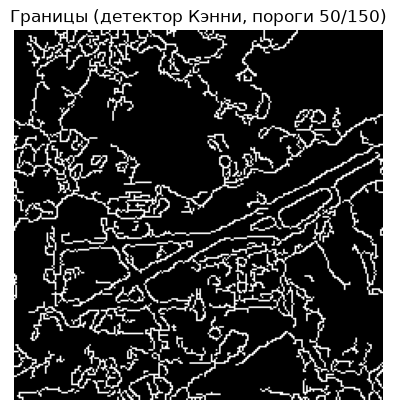

In [4]:
edges = cv2.Canny(image_med, 50, 150, apertureSize=3)
print('Граничных точек после Кэнни:', int((edges > 0).sum()))

plt.imshow(edges, cmap='gray')
plt.title('Границы (детектор Кэнни, пороги 50/150)')
plt.axis('off')
plt.show()

In [5]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)
print('Линий с порогом 100 голосов:', len(lines))


Линий с порогом 100 голосов: 2


In [6]:
# вероятностный Хаф: отрезки (x1, y1, x2, y2)
segments = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=40,
                           minLineLength=40, maxLineGap=15).reshape(-1, 4)
lengths = np.hypot(segments[:, 2] - segments[:, 0], segments[:, 3] - segments[:, 1])
angles = np.degrees(np.arctan2(segments[:, 3] - segments[:, 1], segments[:, 2] - segments[:, 0]))

print('Всего отрезков:', len(segments))
print()
print('Топ-5 самых протяжённых участков:')
order = np.argsort(lengths)[::-1]
for idx in order[:5]:
    print('  длина = %5.1f px, угол = %6.1f град, (%d, %d) - (%d, %d)'
          % (lengths[idx], angles[idx], *segments[idx]))

Всего отрезков: 93

Топ-5 самых протяжённых участков:
  длина = 237.5 px, угол =  -27.9 град, (12, 180) - (222, 69)
  длина = 217.8 px, угол =   45.0 град, (62, 70) - (216, 224)
  длина = 214.9 px, угол =   31.1 град, (3, 71) - (187, 182)
  длина = 214.3 px, угол =  -28.1 град, (28, 181) - (217, 80)
  длина = 206.3 px, угол =  -30.9 град, (30, 220) - (207, 114)


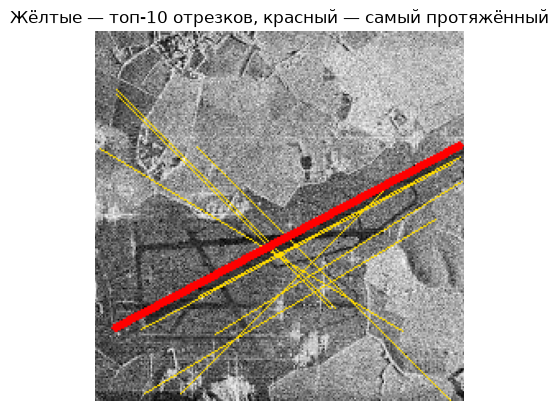

Самый протяжённый участок: 238 px, угол -27.9 град


In [7]:
best_idx = int(np.argmax(lengths))

vis = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
for idx in order[:10]:
    x1, y1, x2, y2 = segments[idx]
    cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 220, 0), 1)
x1, y1, x2, y2 = segments[best_idx]
cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 3)

plt.imshow(vis)
plt.title('Жёлтые — топ-10 отрезков, красный — самый протяжённый')
plt.axis('off')
plt.show()

print('Самый протяжённый участок: %.0f px, угол %.1f град' % (lengths[best_idx], angles[best_idx]))


## Бинаризация
Полоса тёмная, поэтому объект — пиксели $I < T$, в масках показываю их белым.

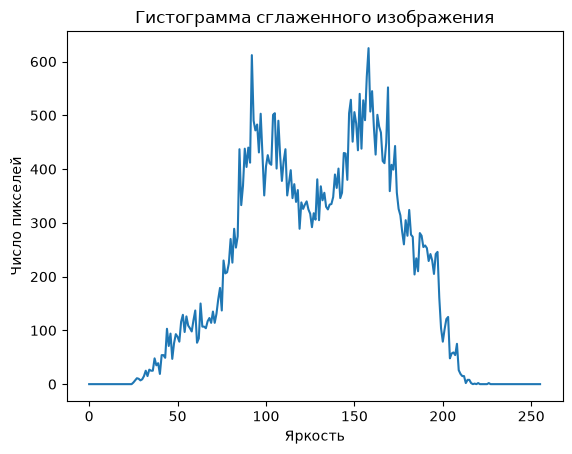

In [8]:
hist = cv2.calcHist([image_med], [0], None, [256], (0, 256))

plt.plot(hist)
plt.title('Гистограмма сглаженного изображения')
plt.xlabel('Яркость')
plt.ylabel('Число пикселей')
plt.show()


T = 50: доля белых = 0.019
T = 60: доля белых = 0.040
T = 70: доля белых = 0.062
T = 80: доля белых = 0.096


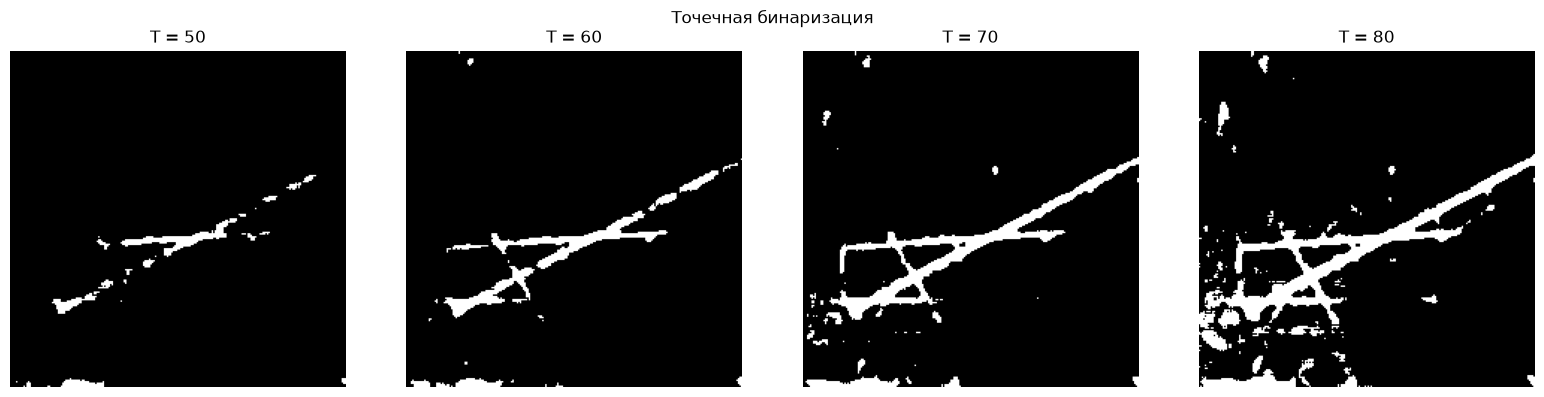

In [9]:
# белым — полоса (I < T)
plt.figure(figsize=(16, 4))
for i, T in enumerate([50, 60, 70, 80], 1):
    mask = (image_med < T).astype(np.uint8) * 255
    print('T = %d: доля белых = %.3f' % (T, (image_med < T).mean()))
    plt.subplot(1, 4, i)
    plt.imshow(mask, cmap='gray')
    plt.title('T = %d' % T)
    plt.axis('off')
plt.suptitle('Точечная бинаризация')
plt.tight_layout()
plt.show()


Автопороги: Отсу, треугольник, итеративный (своя реализация), адаптивный.

In [10]:
t_otsu, _ = cv2.threshold(image_med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_triangle, _ = cv2.threshold(image_med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

def iterative_threshold(img, tol=0.5, max_iter=100):
    t = (img.min() + img.max()) / 2.0
    for _ in range(max_iter):
        m1 = img[img < t].mean()
        m2 = img[img >= t].mean()
        t_new = (m1 + m2) / 2.0
        if abs(t_new - t) < tol:
            break
        t = t_new
    return t

t_iter = iterative_threshold(image_med)

print('Отсу: %.1f, треугольник: %.1f, итеративный: %.1f' % (t_otsu, t_triangle, t_iter))
print('Маски итеративного и Отсу совпадают на %.3f' % ((image_med < t_iter) == (image_med < t_otsu)).mean())


Отсу: 128.0, треугольник: 141.0, итеративный: 128.0
Маски итеративного и Отсу совпадают на 0.994


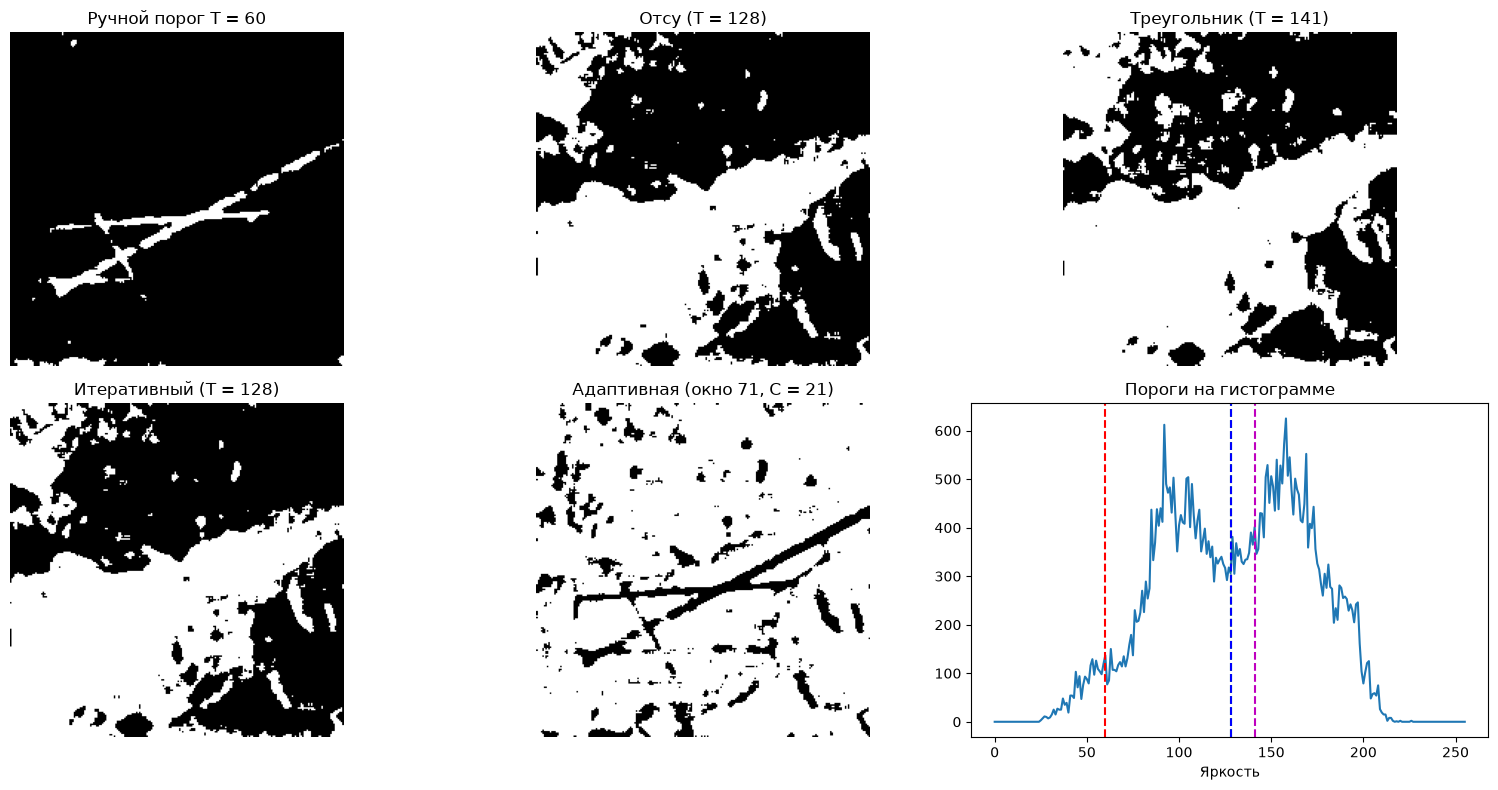

Автопороги дают около 50% белых — полоса сливается с шумом, беру ручной T = 60


In [11]:
bin_adaptive = cv2.adaptiveThreshold(image_med, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 71, 21)

masks = [
    ('Ручной порог T = 60', (image_med < 60).astype(np.uint8) * 255),
    ('Отсу (T = %d)' % t_otsu, ((image_med < t_otsu).astype(np.uint8)) * 255),
    ('Треугольник (T = %d)' % t_triangle, ((image_med < t_triangle).astype(np.uint8)) * 255),
    ('Итеративный (T = %.0f)' % t_iter, ((image_med < t_iter).astype(np.uint8)) * 255),
    ('Адаптивная (окно 71, C = 21)', bin_adaptive),
]

plt.figure(figsize=(16, 8))
for i, (title, m) in enumerate(masks, 1):
    plt.subplot(2, 3, i)
    plt.imshow(m, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.plot(hist)
for t, c in [(60, 'r'), (t_otsu, 'g'), (t_triangle, 'm'), (t_iter, 'b')]:
    plt.axvline(t, color=c, linestyle='--')
plt.title('Пороги на гистограмме')
plt.xlabel('Яркость')
plt.tight_layout()
plt.show()

print('Автопороги дают около 50% белых — полоса сливается с шумом, беру ручной T = 60')


## Полоса
Замыкание склеивает разрывы, открытие убирает шум, полоса — самая протяжённая компонента.

Связных компонент после морфологии: 5


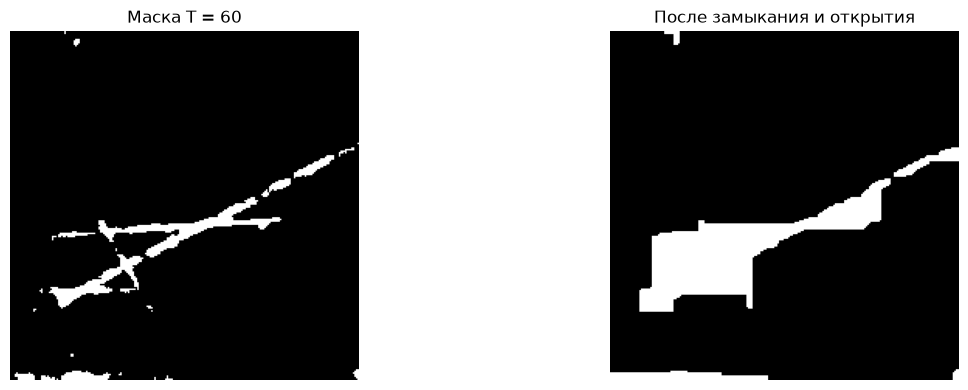

In [12]:
road_mask = (image_med < 60).astype(np.uint8) * 255

# замыкание склеивает полосу, открытие убирает шум
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (19, 19))
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
road_closed = cv2.morphologyEx(road_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
road_clean = cv2.morphologyEx(road_closed, cv2.MORPH_OPEN, kernel_open, iterations=1)

n_comp, labels, stats, centroids = cv2.connectedComponentsWithStats(road_clean, connectivity=8)
print('Связных компонент после морфологии:', n_comp - 1)
diag = np.hypot(stats[:, cv2.CC_STAT_WIDTH], stats[:, cv2.CC_STAT_HEIGHT])

plt.figure(figsize=(14, 4))
for i, (title, m) in enumerate([('Маска T = 60', road_mask),
                                ('После замыкания и открытия', road_clean)]):
    plt.subplot(1, 2, i + 1)
    plt.imshow(m, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [13]:
road_idx = int(np.argmax(diag[1:]) + 1)
road_comp = (labels == road_idx).astype(np.uint8)

# направление полосы — главная ось (собственный вектор ковариации координат)
ys, xs = np.nonzero(road_comp)
pts = np.stack([xs - xs.mean(), ys - ys.mean()])
cov = pts @ pts.T / len(xs)
eigvals, eigvecs = np.linalg.eigh(cov)
main_axis = eigvecs[:, np.argmax(eigvals)]
road_angle = math.degrees(math.atan2(main_axis[1], main_axis[0]))
if road_angle > 90:
    road_angle -= 180

x, y, w, h, area = stats[road_idx]
print('Полоса: площадь %d пикселей (%.1f%%), bbox %dx%d в (x=%d, y=%d)'
      % (area, 100.0 * area / image_gray.size, w, h, x, y))
print('Главная ось: %.1f град (Хаф дал %.1f град)' % (road_angle, angles[best_idx]))


Полоса: площадь 4476 пикселей (8.8%), bbox 162x86 в (x=19, y=95)
Главная ось: -19.8 град (Хаф дал -27.9 град)


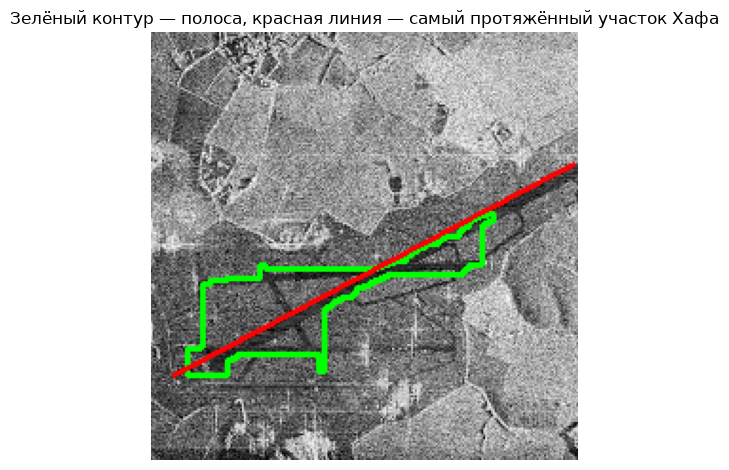

In [14]:
result = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
contours, _ = cv2.findContours(road_comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)
x1, y1, x2, y2 = segments[best_idx]
cv2.line(result, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)

plt.imshow(result)
plt.title('Зелёный контур — полоса, красная линия — самый протяжённый участок Хафа')
plt.axis('off')
plt.tight_layout()
plt.show()
